# Direct Column Breakthrough simulation

This example shows how to set up and run a direct column breakthrough (DCB) simulation
as described in [Haghpanah et al. 2013](http://dx.doi.org/10.1021/ie302658y).
This simulation inolves injection of a two component flue gas (CO2 and N2)
into a column of Zeolite 13X initially filled with N2.

Adsorption onto Zeolite 13X is modelled with a dual-site Langumuir adsorption isotherm.
Injection flow rate is fixed at the right hand side of the column and the left hand side of the column
is open.
There is no heat transfer between the column and the column wall.

First we load the necessary modules

In [1]:
import Jutul: si_unit
import Mocca

Then we define parameters which we want. We have defined a structure containing
parameters from Haghpanah et al. 2013 which we load now.
As we are doing a DCB simulation we will set the heat transfer coefficient between
the column and the wall and the wall and the outside to zero.

In [2]:
constants = Mocca.HaghpanahConstants{Float64}(h_in = 0.0, h_out = 0.0);

We set up a two component adsorption system. This system type is associated
with the appropriate equations and primary and secondary variables.

In [3]:
system = Mocca.TwoComponentAdsorptionSystem(constants);

# Define the model
Next we need to make the model. This model contains information about
the domain (grid) over which we will solve the equations and information
about the system of equations which we are solving.

We formulate our velocity equation in the following form:

$$
v = -\frac{k}{\mu}(\nabla P)
$$

where `k` is known as the permeability.
In this instance we use the pressure drop equation for plug flow in a packed
bed:

$$
v=-\frac{4}{150}\frac{\epsilon^3}{(1-\epsilon)^2} r_{i n}^2 \frac{1}{\mu}(\nabla P)
$$

The permeability of the system is then given by:

$$
k = \frac{4}{150}\frac{\epsilon^3}{(1-\epsilon)^2} r_{i n}^2
$$

In [4]:
ncells = 200
model = Mocca.setup_process_model(system; ncells = ncells);

# Setup the initial state and parameters of the simulation
Initial values for pressure and temperature of the system

In [5]:
bar = si_unit(:bar);
P_init = 1*bar;
T_init = 298.15;
Tw_init = constants.T_a;

To avoid numerical errors we set the initial CO2 concentration to be very
small and not exactly zero

In [6]:
yCO2_2 = 1e-10
y_init = [yCO2_2, 1.0 - yCO2_2] # [CO2, N2]

state0 = Mocca.setup_process_state(model;
    Pressure = P_init,
    Temperature = T_init,
    WallTemperature = Tw_init,
    y = y_init
)
parameters = Mocca.setup_process_parameters(model);

# Setup the timestepping and boundary conditions

For the DCB we are only running the adsorption stage of a VSA process.
We will use a total time of 5000 seconds with a single report step

In [7]:
t_ads = 5000.0;
maxdt = 5000.0;

For the DCB we set up boundary conditions for just an adsorption stage. This sets a fixed
velocity, concentration and temperature at the inlet, and fixed pressure at
the outlet. By convention we assume the inlet bc is applied on the left hand
side and the outlet bc is applied on the right hand side.

In [8]:
sim_forces, timesteps = Mocca.setup_forces(model,[t_ads],["adsorption"];
    num_cycles=1,max_dt = maxdt);

Specify target change of the different state variables for dynamic timestepping

In [9]:
timestep_selector_cfg = (y = 0.01, Temperature = 10.0, Pressure = 10.0);

# Run the simulation
Collect everything into a fully specified simulation case and start the simulation

In [10]:
case = Mocca.MoccaCase(model, timesteps, sim_forces; state0 = state0, parameters = parameters)
states, timesteps_out = Mocca.simulate_process(case;
    timestep_selector_cfg = timestep_selector_cfg,
    output_substates = true,
);

Jutul: Simulating 1 hour, 23.33 minutes as 1 report steps
╭────────────────┬──────────┬───────────────┬──────────╮
│ Iteration type │ Avg/step │  Avg/ministep │    Total │
│                │  1 steps │ 302 ministeps │ (wasted) │
├────────────────┼──────────┼───────────────┼──────────┤
│ Newton         │    614.0 │       2.03311 │  614 (0) │
│ Linearization  │    916.0 │       3.03311 │  916 (0) │
│ Linear solver  │    614.0 │       2.03311 │  614 (0) │
│ Precond apply  │      0.0 │           0.0 │    0 (0) │
╰────────────────┴──────────┴───────────────┴──────────╯
╭───────────────┬─────────┬────────────┬─────────╮
│ Timing type   │    Each │   Relative │   Total │
│               │      ms │ Percentage │       s │
├───────────────┼─────────┼────────────┼─────────┤
│ Properties    │  0.0546 │     0.28 % │  0.0335 │
│ Equations     │  4.0505 │    31.21 % │  3.7102 │
│ Assembly      │  0.5577 │     4.30 % │  0.5108 │
│ Linear solve  │  4.7693 │    24.63 % │  2.9284 │
│ Linear setup  │  0.

# Visualisation
We plot primary variables at the outlet through time

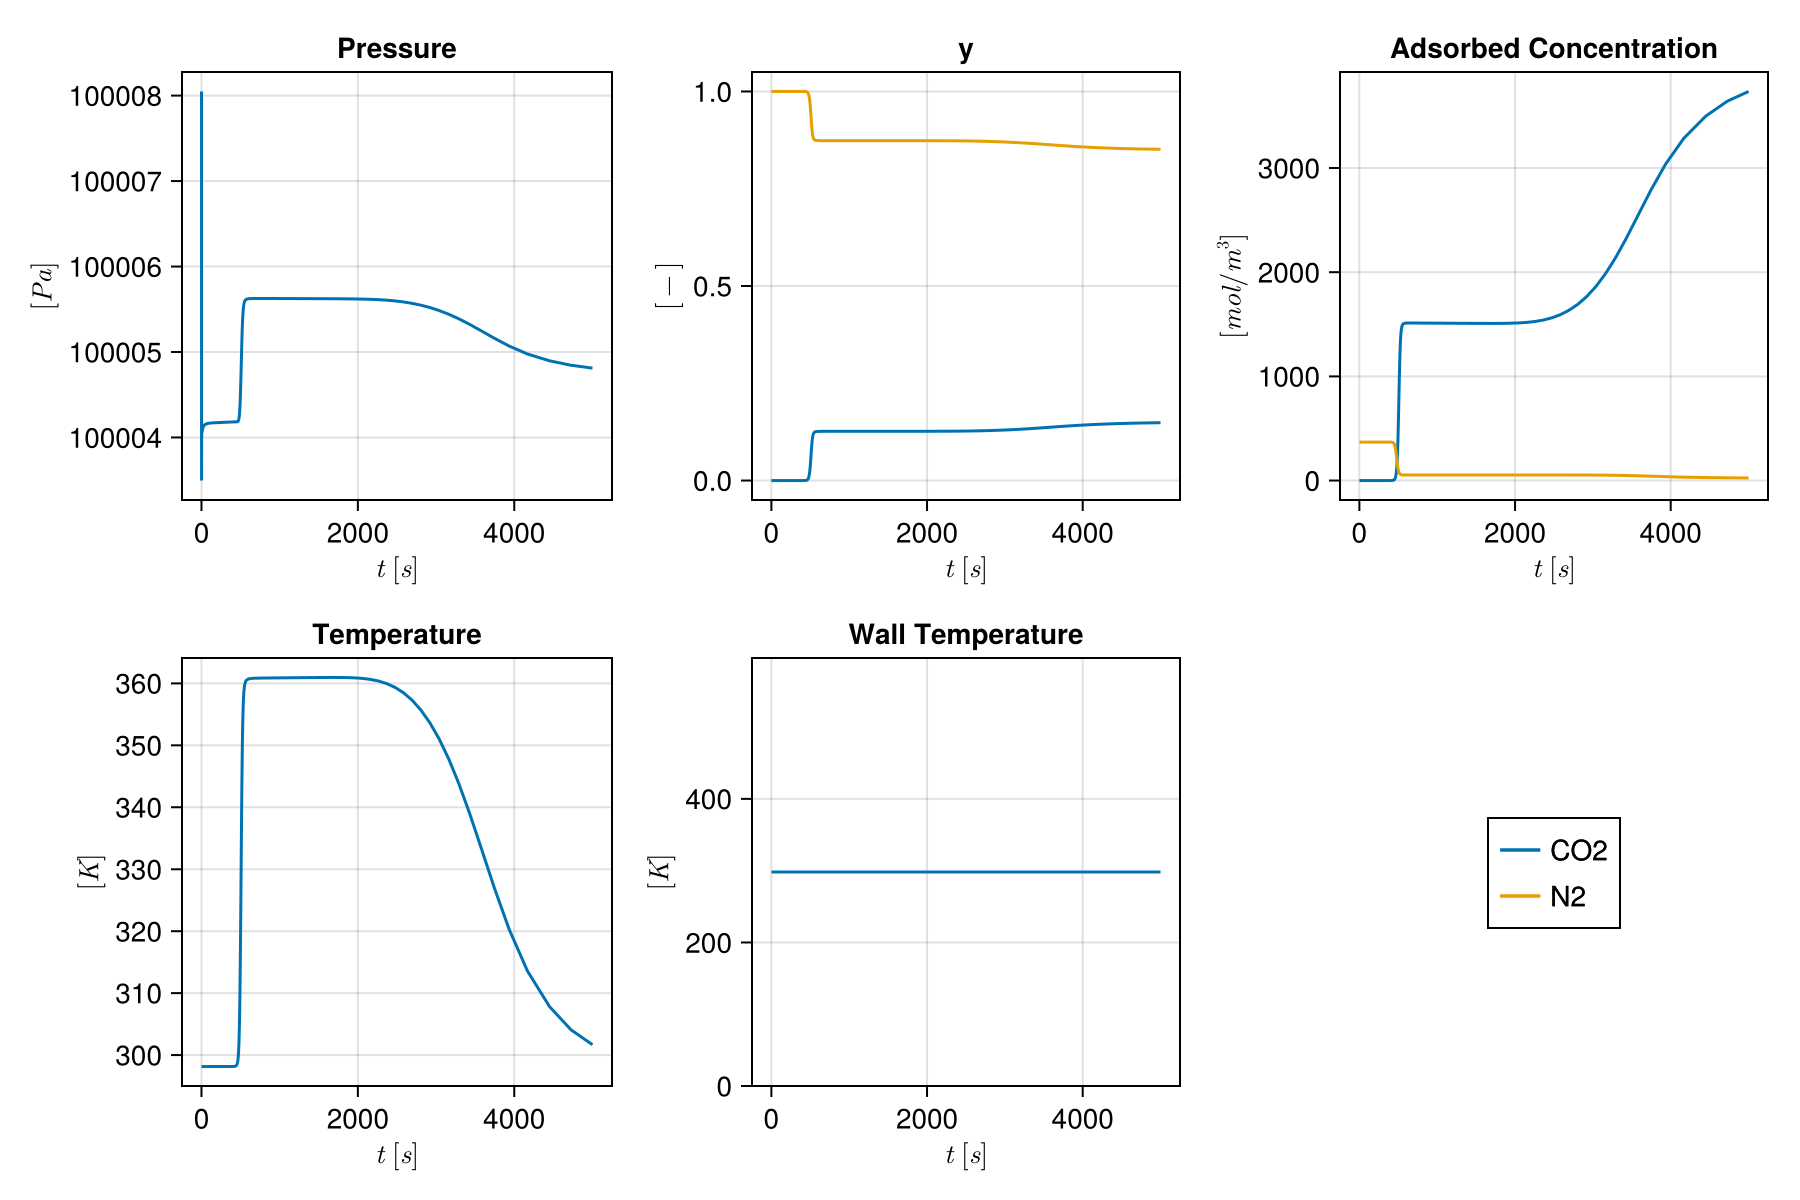

In [11]:
outlet_cell = ncells
f_outlet = Mocca.plot_cell(states, model, timesteps_out, outlet_cell)

We also plot primary variables along the column at the end of the simulation

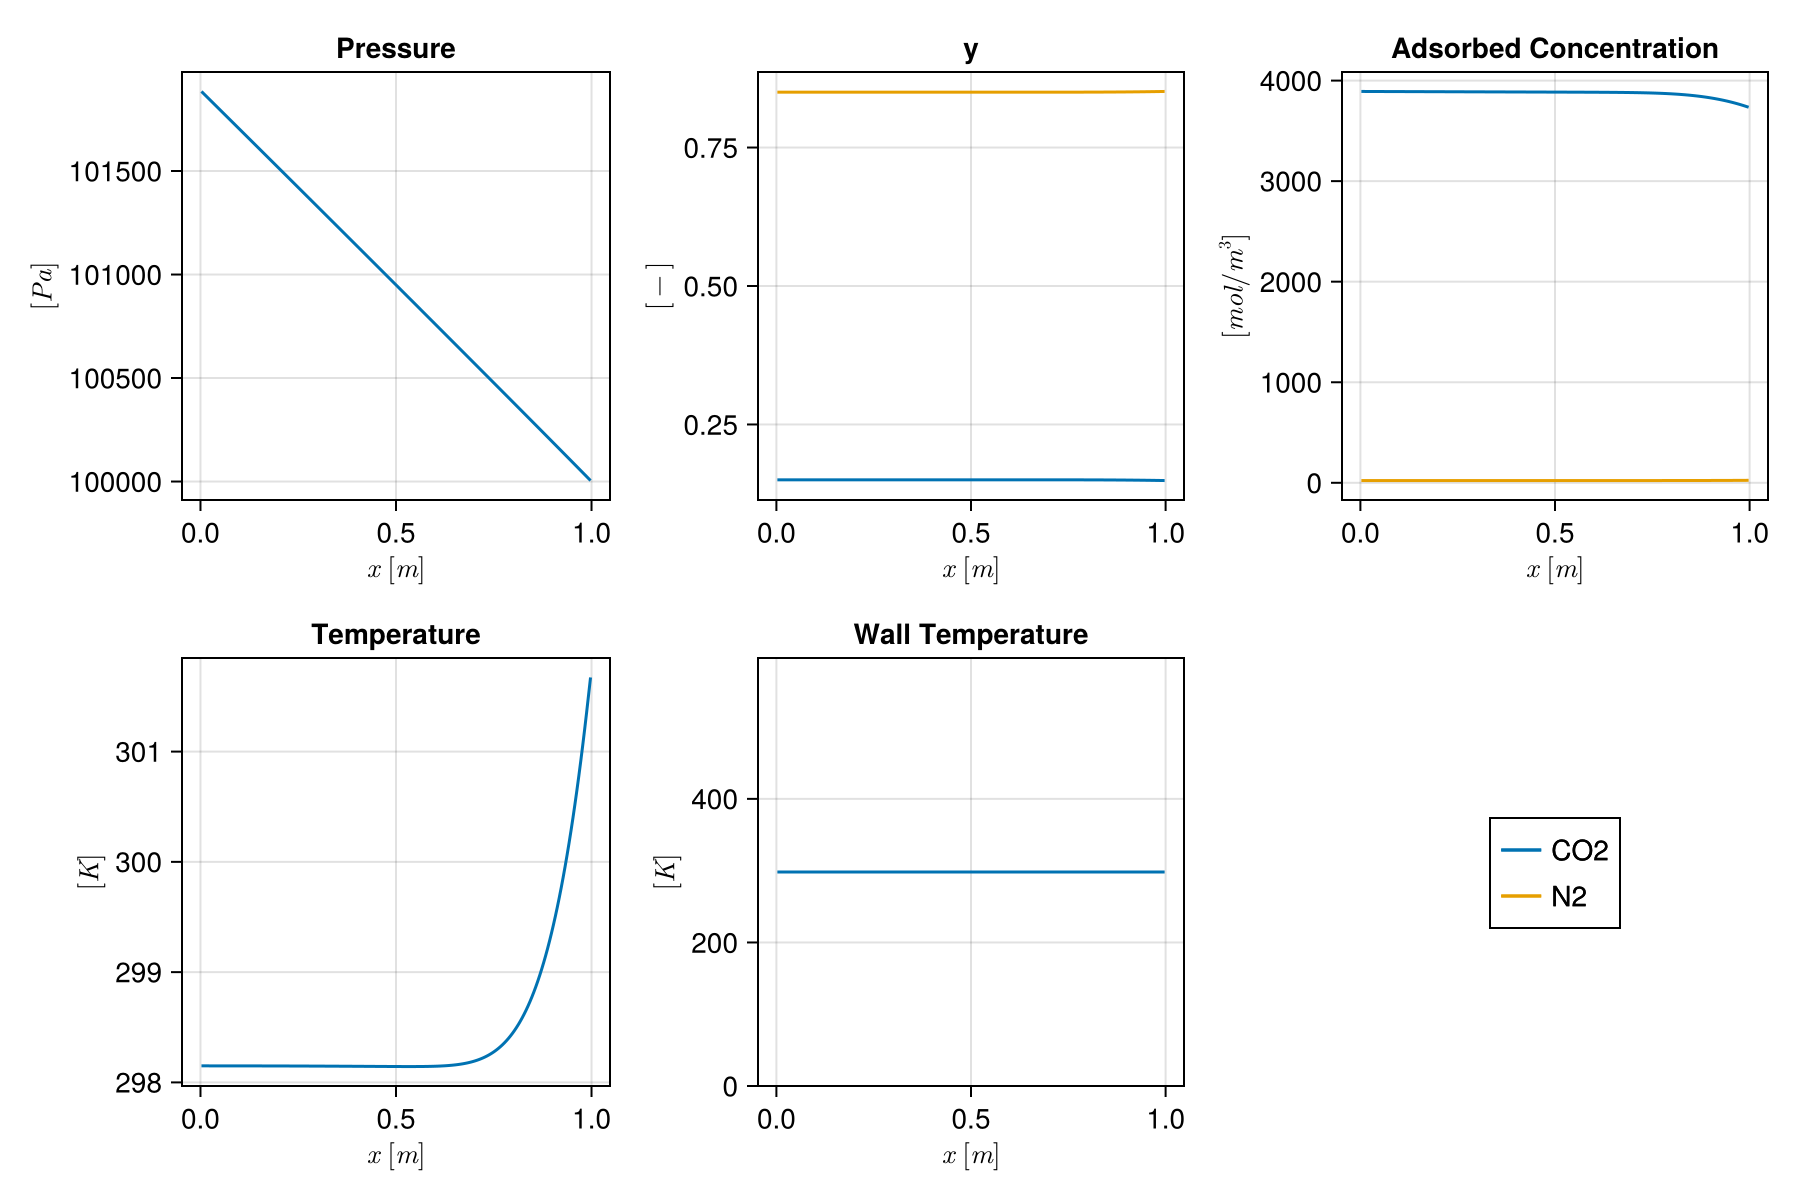

In [12]:
f_column = Mocca.plot_state(states[end], model)

## Example on GitHub
If you would like to run this example yourself, it can be downloaded from [the Mocca.jl GitHub repository](https://github.com/sintefmath/Mocca.jl/blob/main/examples/simulate_DCB.jl).

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*